<a href="https://colab.research.google.com/github/CristianoCoelhoSilva/Python/blob/master/Script.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import seaborn
import matplotlib
import pydotplus
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_selector, make_column_transformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import RFE
from sklearn.linear_model import RidgeCV, LassoCV, Ridge, Lasso#Loading the dataset
from sklearn.metrics import confusion_matrix
from sklearn.externals.six import StringIO  
from IPython.display import Image  
from sklearn.tree import export_graphviz
%matplotlib inline




/usr/local/lib/python3.6/dist-packages/statsmodels/tools/_testing.py:19: FutureWarning: pandas.util.testing is deprecated. Use the functions in the public API at pandas.testing instead.
  import pandas.util.testing as tm
/usr/local/lib/python3.6/dist-packages/sklearn/externals/six.py:31: FutureWarning: The module is deprecated in version 0.21 and will be removed in version 0.23 since we've dropped support for Python 2.7. Please rely on the official version of six (https://pypi.org/project/six/).
  "(https://pypi.org/project/six/).", FutureWarning)


In [ ]:
#Arquivo completo
df = pd.read_csv(r"https://raw.githubusercontent.com/CristianoCoelhoSilva/Python/master/Python/covid_limit.csv")

df.drop(["ENTUBADO"], axis="columns", inplace=True)

In [ ]:
#df['IDADE'].corr(df['FEBRE'])

In [ ]:
#df.corr()

In [ ]:
#df.corr().style.format("{:.2}").background_gradient(cmap=plt.get_cmap('coolwarm'), axis=1)

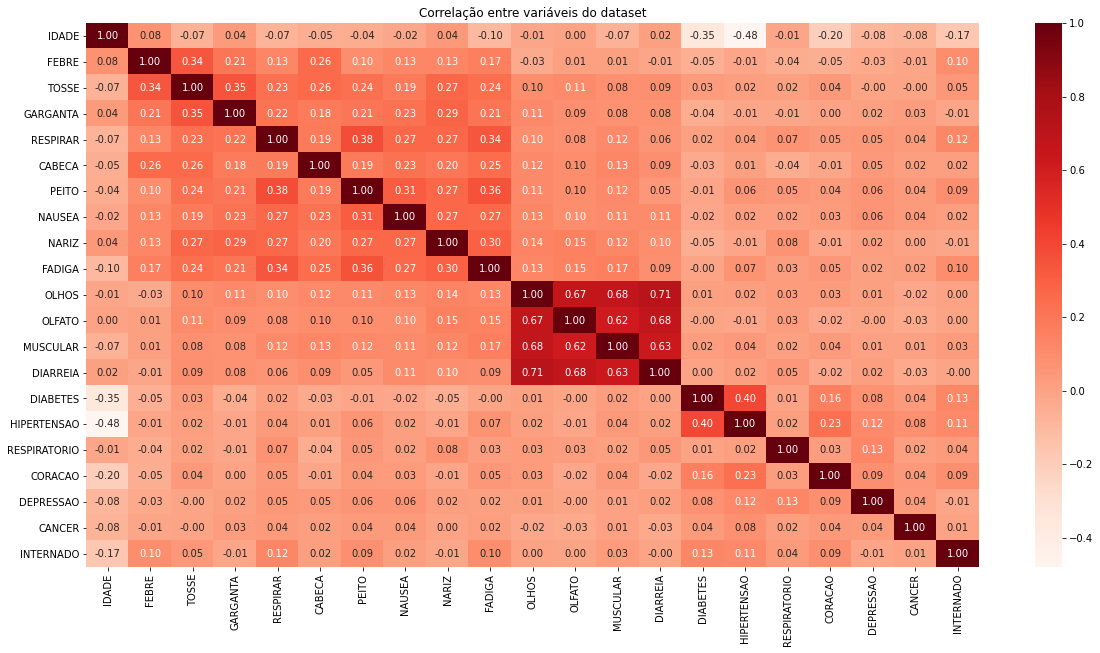

In [ ]:
a4_dims = (20, 10)
fig, ax = plt.subplots(figsize=a4_dims)

seaborn.heatmap(df.corr(),
            annot = True,
            fmt = '.2f',
            cmap='Reds')
plt.title('Correlação entre variáveis do dataset')
plt.show()

In [ ]:
##Fazendo o holdout

X = df.drop(['INTERNADO'], axis = "columns")
y = df.INTERNADO

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 13)

# Cria nosso pipeline para pré-processamento com imputação, dummização e normalização
encoder_imputer_scaled_transformer = make_column_transformer(
    (make_pipeline(
        (KNNImputer(n_neighbors = 3)),
        (StandardScaler())
    ) , make_column_selector(dtype_include = np.number)),
    (make_pipeline(
        SimpleImputer(strategy = 'most_frequent'),
        OneHotEncoder(handle_unknown = 'ignore'),
    ), make_column_selector(dtype_exclude = np.number)),
    remainder = 'passthrough'
)

encoder_imputer_scaled_transformer.fit(X_train)

X_train_processed = encoder_imputer_scaled_transformer.transform(X_train)
X_test_processed = encoder_imputer_scaled_transformer.transform(X_test)

model  = RandomForestClassifier()
#model = KNeighborsClassifier(n_neighbors = 3)
model.fit(X_train_processed, y_train)# Mostrando importância de cada feature
model.feature_importances_

array([0.37435687, 0.03632926, 0.03631398, 0.03630669, 0.04864341,
       0.03752451, 0.0342964 , 0.03331365, 0.03361378, 0.04596061,
       0.02347078, 0.05525134, 0.03682095, 0.04204484, 0.03299118,
       0.03591598, 0.02011244, 0.01914004, 0.01104574, 0.00654753])

Text(0.5, 1.0, 'Importância de cada feature')

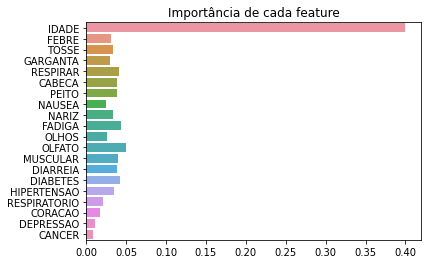

In [ ]:
importances = pd.Series(data=model.feature_importances_, index=X.columns)
seaborn.barplot(x=importances, y=importances.index, orient='h').set_title('Importância de cada feature')

In [ ]:
#apply SelectKBest class to extract top 10 best features
'''bestfeatures = SelectKBest(score_func=chi2, k=10)
fit = bestfeatures.fit(X,y)

dfscores = pd.DataFrame(fit.scores_)
dfcolumns = pd.DataFrame(X.columns)
#concat two dataframes for better visualization 
featureScores = pd.concat([dfcolumns,dfscores],axis=1)
featureScores.columns = ['Specs','Score']  #naming the dataframe columns
print(featureScores.nlargest(10,'Score'))  #print 10 best features'''

"bestfeatures = SelectKBest(score_func=chi2, k=10)\nfit = bestfeatures.fit(X,y)\n\ndfscores = pd.DataFrame(fit.scores_)\ndfcolumns = pd.DataFrame(X.columns)\n#concat two dataframes for better visualization \nfeatureScores = pd.concat([dfcolumns,dfscores],axis=1)\nfeatureScores.columns = ['Specs','Score']  #naming the dataframe columns\nprint(featureScores.nlargest(10,'Score'))  #print 10 best features"

In [ ]:
reg = LassoCV()
reg.fit(X, y)
print("Best alpha using built-in LassoCV: %f" % reg.alpha_)
print("Best score using built-in LassoCV: %f" %reg.score(X,y))
coef = pd.Series(reg.coef_, index = X.columns)

Best alpha using built-in LassoCV: 0.000784
Best score using built-in LassoCV: 0.068599


Text(0.5, 1.0, 'Feature importance using Lasso Model')

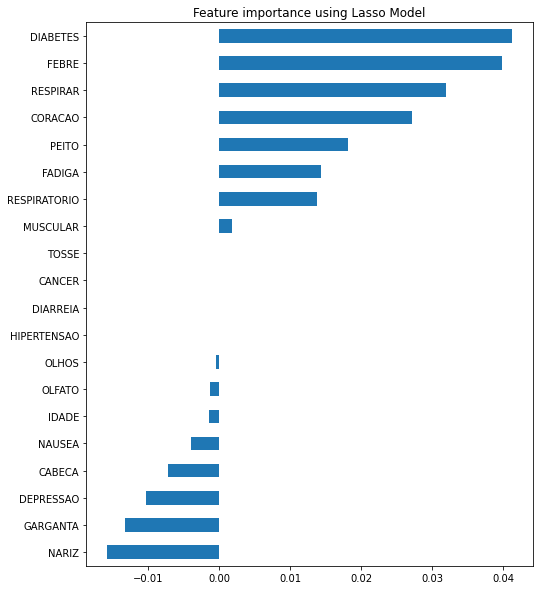

In [ ]:
imp_coef = coef.sort_values()
import matplotlib
matplotlib.rcParams['figure.figsize'] = (8.0, 10.0)
imp_coef.plot(kind = "barh")
plt.title("Feature importance using Lasso Model")

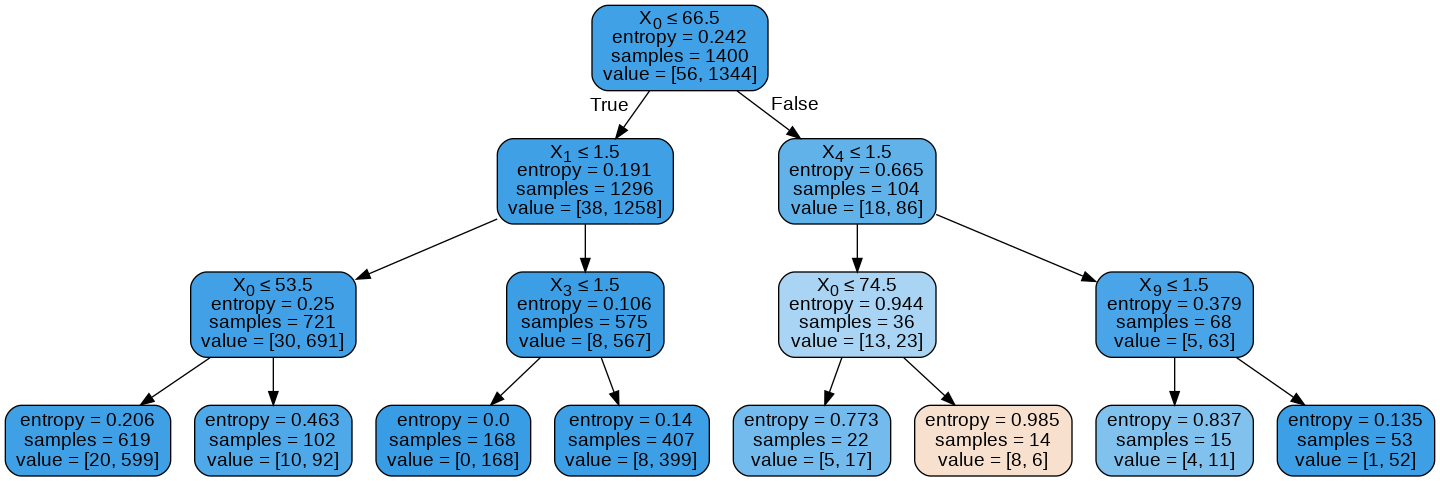

In [ ]:
clf = DecisionTreeClassifier(criterion="entropy", max_depth=3)
clf = clf.fit(X_train, y_train) # o método fit "treina o modelo"

preds = clf.predict(X_test)

confusion_matrix(y_test, preds)

dot_data = StringIO()
export_graphviz(clf, out_file=dot_data,  
                filled=True, rounded=True,
                special_characters=True)
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())  
Image(graph.create_png())

## Cross Validation

In [ ]:
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_selector, make_column_transformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix
from sklearn.externals.six import StringIO  
from IPython.display import Image  
from sklearn.tree import export_graphviz
import pydotplus
from sklearn.model_selection import KFold

In [ ]:
X_processed = encoder_imputer_scaled_transformer.fit_transform(X)

In [ ]:
#import seaborn
#import matplotlib.pyplot as plt
#from sklearn.metrics import roc_auc_score

#results_cross_validation = []
#for k in range(3, 51):
#  for time in range(30):
#    kf = KFold(n_splits=k, shuffle=True).split(X_processed)
#    scores = cross_val_score(model, X_processed, y, cv=kf, scoring='roc_auc')
#    #scores = cross_val_score(model, X_processed, y, cv=kf, scoring='precision_macro')
#    results_cross_validation = results_cross_validation + [[k, time, np.mean(scores)]]

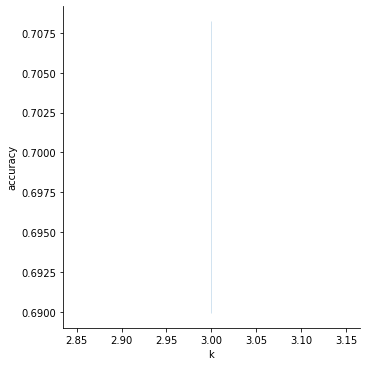

In [ ]:
df = pd.DataFrame(results_cross_validation,columns=['k','time_id', 'accuracy'])

seaborn.relplot(data = df,
                x = 'k',
                y = 'accuracy',
                kind = 'line')
plt.show()

In [ ]:
results = pd.DataFrame(columns=['n_neighbors', 'roc_auc'])

for n_neighbors in range(1, 31):
  knn = KNeighborsClassifier(n_neighbors = n_neighbors)
  scores = cross_val_score(knn, X_train_processed, y_train, cv=9, scoring='roc_auc')
  results = results.append({'n_neighbors' : n_neighbors, 'roc_auc' : np.mean(scores)}, ignore_index = True)
  
results

,n_neighbors,roc_auc
0,1.0,0.505408
1,2.0,0.545238
2,3.0,0.560277
3,4.0,0.556530
4,5.0,0.582065
5,6.0,0.586401
6,7.0,0.573949
7,8.0,0.569240
8,9.0,0.559078
9,10.0,0.560838


O k que maximiza a acurácia no conjunto de treinamento é: 30


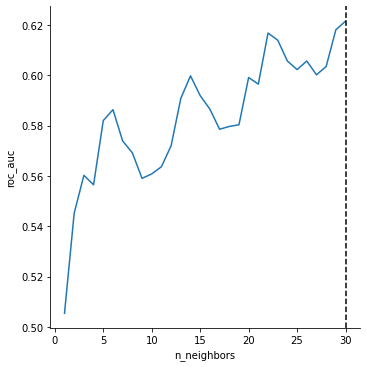

In [ ]:
import seaborn
import matplotlib.pyplot as plt

melhor_k = int(results[results.roc_auc == results.roc_auc.max()]['n_neighbors'].values[0])

seaborn.relplot(data = results,
                x = 'n_neighbors',
                y = 'roc_auc',
                kind = 'line')
plt.axvline(x=melhor_k, color="black", linestyle= "--")

print("O k que maximiza a acurácia no conjunto de treinamento é: {}".format(melhor_k))

## Script

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Perceptron

pipeline_estendido = Pipeline([
    ("pre_process", make_column_transformer(
                              (Pipeline([
                                  ('imputer', KNNImputer(n_neighbors = 3)),
                                  ('scaler', StandardScaler())
                              ]) , make_column_selector(dtype_include = np.number)),
                              (Pipeline([
                                  ("imputer", SimpleImputer(strategy = 'most_frequent', fill_value = "unknown")),
                                  ("encoder", OneHotEncoder(handle_unknown = 'ignore'))
                              ]), make_column_selector(dtype_exclude = np.number))
                          )),
    ##("knn", KNeighborsClassifier())
    ##('tree', DecisionTreeClassifier())
    ('Random_forest',RandomForestClassifier())
])

In [ ]:
import pprint as pp

pp.pprint(sorted(pipeline_estendido.get_params().keys()))

['Random_forest',
 'Random_forest__bootstrap',
 'Random_forest__ccp_alpha',
 'Random_forest__class_weight',
 'Random_forest__criterion',
 'Random_forest__max_depth',
 'Random_forest__max_features',
 'Random_forest__max_leaf_nodes',
 'Random_forest__max_samples',
 'Random_forest__min_impurity_decrease',
 'Random_forest__min_impurity_split',
 'Random_forest__min_samples_leaf',
 'Random_forest__min_samples_split',
 'Random_forest__min_weight_fraction_leaf',
 'Random_forest__n_estimators',
 'Random_forest__n_jobs',
 'Random_forest__oob_score',
 'Random_forest__random_state',
 'Random_forest__verbose',
 'Random_forest__warm_start',
 'memory',
 'pre_process',
 'pre_process__n_jobs',
 'pre_process__pipeline-1',
 'pre_process__pipeline-1__imputer',
 'pre_process__pipeline-1__imputer__add_indicator',
 'pre_process__pipeline-1__imputer__copy',
 'pre_process__pipeline-1__imputer__metric',
 'pre_process__pipeline-1__imputer__missing_values',
 'pre_process__pipeline-1__imputer__n_neighbors',
 'pre_

In [ ]:
#Knn
#param_grid_estendido = {
#    "pre_process__pipeline-1__imputer__n_neighbors": range(1, 5),
#    "pre_process__pipeline-2__imputer__strategy": ['most_frequent', 'constant'],
#    "knn__n_neighbors": range(1, 2)
#}

#Decision Tree
#param_grid_estendido = {
#    "pre_process__pipeline-1__imputer__n_neighbors": range(1, 5),
#    "pre_process__pipeline-2__imputer__strategy": ['most_frequent', 'constant'],
#    "tree__min_samples_leaf": range(1, 3)
#}

#Random_forest
param_grid_estendido = {
    "pre_process__pipeline-1__imputer__n_neighbors": range(1, 5),
    "pre_process__pipeline-2__imputer__strategy": ['most_frequent', 'constant'],
    "Random_forest__n_estimators": range(1, 10)
}

classificador_estendido = GridSearchCV(estimator = pipeline_estendido,
                                       param_grid = param_grid_estendido,
                                       scoring = "roc_auc",
                                       cv = 5,
                                       refit = True)

In [ ]:
classificador_estendido.fit(X_train, y_train)

In [ ]:
print("Melhor parâmetro do modelo knn: ")
print(classificador_estendido.best_params_)

print("Desempenho médio no fold de teste: ")
print(np.mean(classificador_estendido.cv_results_['mean_test_score']))

Melhor parâmetro do modelo knn: 
{'Random_forest__n_estimators': 9, 'pre_process__pipeline-1__imputer__n_neighbors': 2, 'pre_process__pipeline-2__imputer__strategy': 'most_frequent'}
Desempenho médio no fold de teste: 
0.5842015894252968


##Sumarização

In [ ]:
y_pred = classificador_estendido.predict(X_test)

accuracy_score(y_pred = y_pred,
               y_true = y_test)

0.96

In [ ]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_pred = y_pred,
                 y_true = y_test)

array([[  4,  20],
       [  4, 572]])

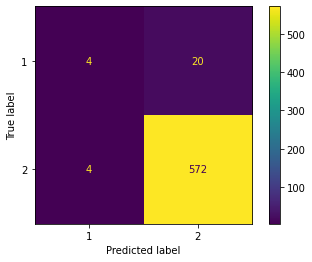

In [ ]:
from sklearn.metrics import plot_confusion_matrix

plot_confusion_matrix(classificador_estendido, X_test, y_test, values_format = '')

In [ ]:
classificador_estendido_roc_auc = GridSearchCV(estimator = pipeline_estendido,
                                                param_grid = param_grid_estendido,
                                                scoring = "roc_auc",
                                                cv = 5,
                                                refit = True)

classificador_estendido_roc_auc.fit(X_train, y_train)

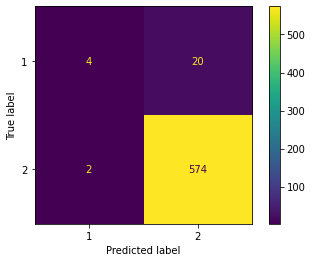

In [ ]:
plot_confusion_matrix(classificador_estendido_roc_auc, X_test, y_test, values_format = '')

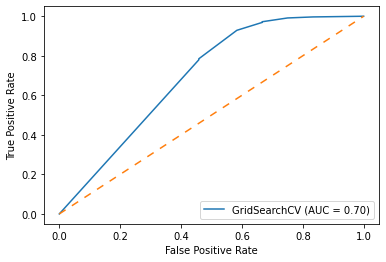

In [ ]:
plot_roc_curve(classificador_estendido_roc_auc, X_test, y_test)
identity_line, = plt.plot([0,1],
                          [0,1])
identity_line.set_dashes([5, 5, 5, 5])